# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [24]:
checker_submits = pd.read_csv('../data/checker_submits.csv', parse_dates=['timestamp'])
checker_submits.head()

,uid,labname,numTrials,timestamp
0,user_4,project1,1,2020-04-17 05:19:02.744528
1,user_4,project1,2,2020-04-17 05:22:45.549397
2,user_4,project1,3,2020-04-17 05:34:24.422370
3,user_4,project1,4,2020-04-17 05:43:27.773992
4,user_4,project1,5,2020-04-17 05:46:32.275104


In [25]:
df = checker_submits[['uid','labname', 'numTrials']].copy()
df['hour'] = checker_submits.timestamp.dt.hour
df['dayofweek'] = checker_submits.timestamp.dt.day_of_week
df.head()

,uid,labname,numTrials,hour,dayofweek
0,user_4,project1,1,5,4
1,user_4,project1,2,5,4
2,user_4,project1,3,5,4
3,user_4,project1,4,5,4
4,user_4,project1,5,5,4


In [26]:
transformers = [
    ('n', StandardScaler(), ['numTrials', 'hour']),
    ('c', OneHotEncoder(sparse_output=False), ['uid', 'labname'])
]

In [27]:
ct = ColumnTransformer(transformers, 
                       verbose_feature_names_out=False,
                       remainder='passthrough')
X = pd.DataFrame(ct.fit_transform(df),
                 columns=ct.get_feature_names_out())
X

,numTrials,hour,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,...,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1,dayofweek
0,-0.788667,-2.562352,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
1,-0.756764,-2.562352,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
2,-0.724861,-2.562352,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
3,-0.692958,-2.562352,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
4,-0.661055,-2.562352,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,-0.533442,0.945382,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0
1682,-0.629151,0.945382,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0
1683,-0.597248,0.945382,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0
1684,-0.565345,0.945382,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0


In [28]:
X.to_csv('../data/dayofweek.csv', index=False)

In [29]:
mode_predict = X.dayofweek.mode()
accuracy_score(X.dayofweek, [mode_predict] * 1686)

0.23487544483985764

## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

In [30]:
X_train = X.drop(columns=['dayofweek'])
y = X.dayofweek

In [31]:
logreg_model = LogisticRegression(random_state=21, fit_intercept=False, solver='liblinear')
logreg_model.fit(X_train,y)
logreg_model.score(X_train, y)

0.6215895610913404

In [32]:
imp = np.sum(np.abs(logreg_model.coef_), axis=0)
np.argsort(imp)[::-1]

array([32, 39, 38, 37, 36, 42, 40, 41,  8, 25,  3,  6, 14, 28, 22, 21, 11,
        7, 16, 15,  4, 13, 23, 31, 19, 27, 12, 10, 24,  5, 20,  9, 18, 17,
        2, 33, 26, 30, 29,  0, 34, 35,  1], dtype=int64)

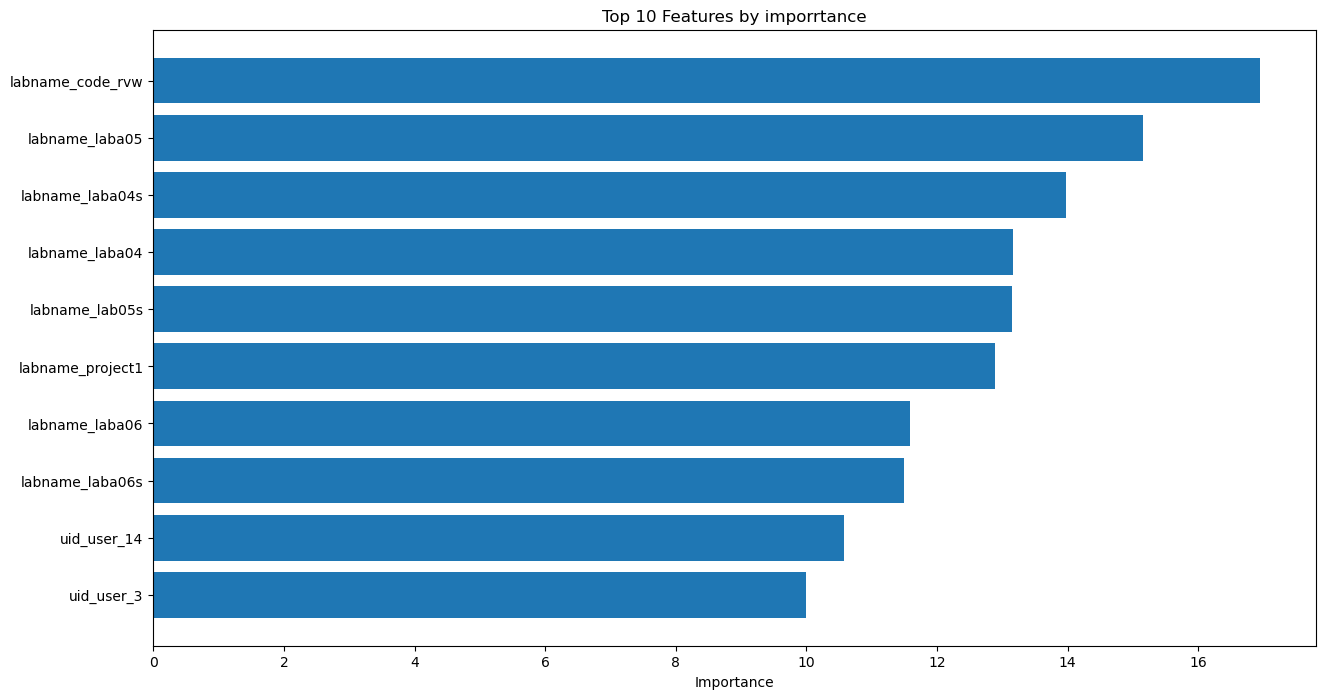

In [33]:
def draw_barh(coefs, names_of_features, top_n=10):
    importance = coefs
    top_n_indx = np.argsort(importance)[::-1][:top_n]
    top_n_features = np.array(names_of_features)[top_n_indx]
    top_n_importance = importance[top_n_indx]

    plt.figure(figsize=(15,8))
    plt.barh(top_n_features, top_n_importance)
    plt.xlabel('Importance')
    plt.title(f'Top {top_n} Features by imporrtance')
    plt.gca().invert_yaxis()
    plt.show()

draw_barh(np.sum(np.abs(logreg_model.coef_), axis=0), X.columns, 10)

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

In [34]:
svc_model = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21))
svc_model.fit(X_train, y)
svc_model.score(X_train, y)

0.6126927639383155

In [35]:
svc_rbf = SVC(kernel='linear', probability=True, random_state=21)
svc_rbf.fit(X_train, y)
svc_rbf.score(X_train, y)

0.702846975088968

In [36]:
svc_poly = SVC(kernel='poly', probability=True, random_state=21)
svc_poly.fit(X_train, y)
svc_poly.score(X_train, y)

0.8594306049822064

In [37]:
all_coef = np.array([estimator.coef_ for estimator in svc_model.estimators_])
all_coef = np.sum(np.abs(all_coef), axis=0)
all_coef[0]

array([0.7317319 , 0.0459405 , 1.04611895, 2.8685459 , 4.42843791,
       4.87830341, 4.74813056, 4.56336572, 2.94936984, 2.82285163,
       2.81527581, 4.35394878, 2.80539862, 3.00830699, 6.00234115,
       2.99168328, 2.57842094, 4.29598823, 2.30110068, 4.3605157 ,
       3.22654894, 2.99219141, 2.81611781, 3.0989063 , 2.83858192,
       4.05433054, 2.84698578, 2.16331225, 3.87444406, 1.97990235,
       4.77484695, 2.96294366, 3.18140795, 1.04611895, 2.17650656,
       2.17556545, 3.90813184, 4.36827147, 3.79094101, 5.22487938,
       5.14037574, 5.10183608, 4.99975295])

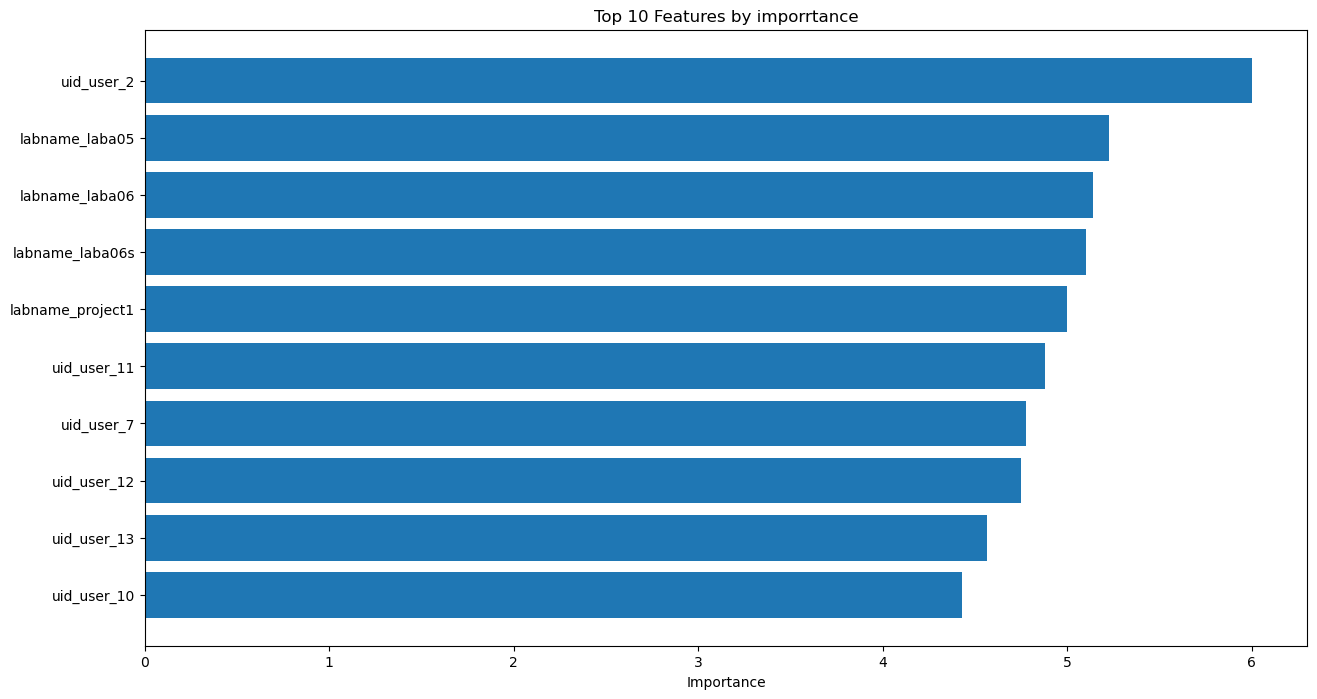

In [38]:
draw_barh(all_coef[0], X.columns, 10)

### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [39]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=21)
tree_model.fit(X_train, y)
tree_model.score(X_train, y)

0.5516014234875445

In [40]:
coef_tree = tree_model.feature_importances_
np.array(coef_tree)

array([0.14931603, 0.06154574, 0.        , 0.        , 0.        ,
       0.        , 0.09837711, 0.        , 0.06455791, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.07642063,
       0.        , 0.        , 0.        , 0.        , 0.01610628,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.06154768, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.05479407, 0.        , 0.08646791,
       0.        , 0.05629871, 0.27456793])

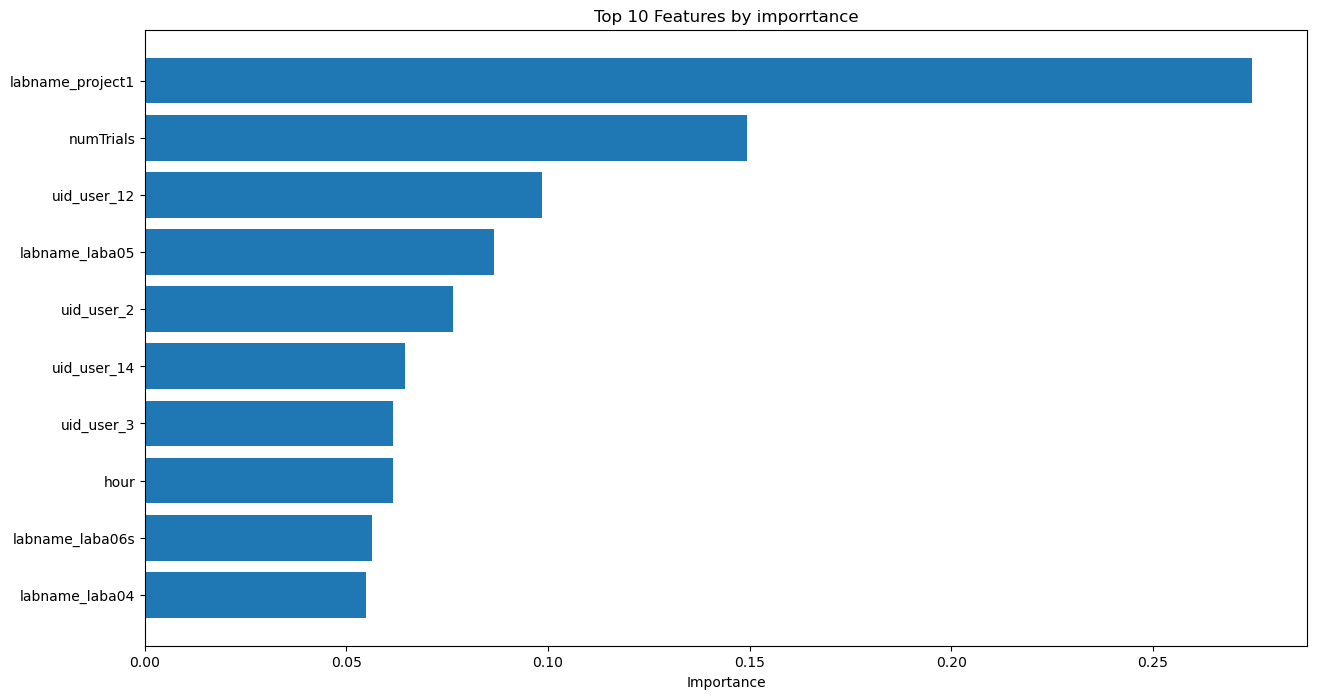

In [41]:
draw_barh(coef_tree, X.columns, 10)

### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [42]:
forest_model = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
forest_model.fit(X_train, y)
forest_model.score(X_train, y)

1.0

In [43]:
forest_coef = forest_model.feature_importances_
forest_coef

array([0.2850512 , 0.17928564, 0.00060824, 0.00699915, 0.01488332,
       0.00271847, 0.01750452, 0.01690517, 0.02729944, 0.00332132,
       0.00734007, 0.01038836, 0.00584606, 0.01472649, 0.02799913,
       0.01464434, 0.01413742, 0.00294055, 0.00181338, 0.01137753,
       0.0217464 , 0.02896417, 0.00620675, 0.01460789, 0.02155901,
       0.02564799, 0.00613813, 0.01500658, 0.01987931, 0.00321527,
       0.00144207, 0.00740036, 0.01622159, 0.00093523, 0.00036829,
       0.00032245, 0.00719308, 0.01602526, 0.01217446, 0.03000572,
       0.00676509, 0.01369153, 0.05869358])

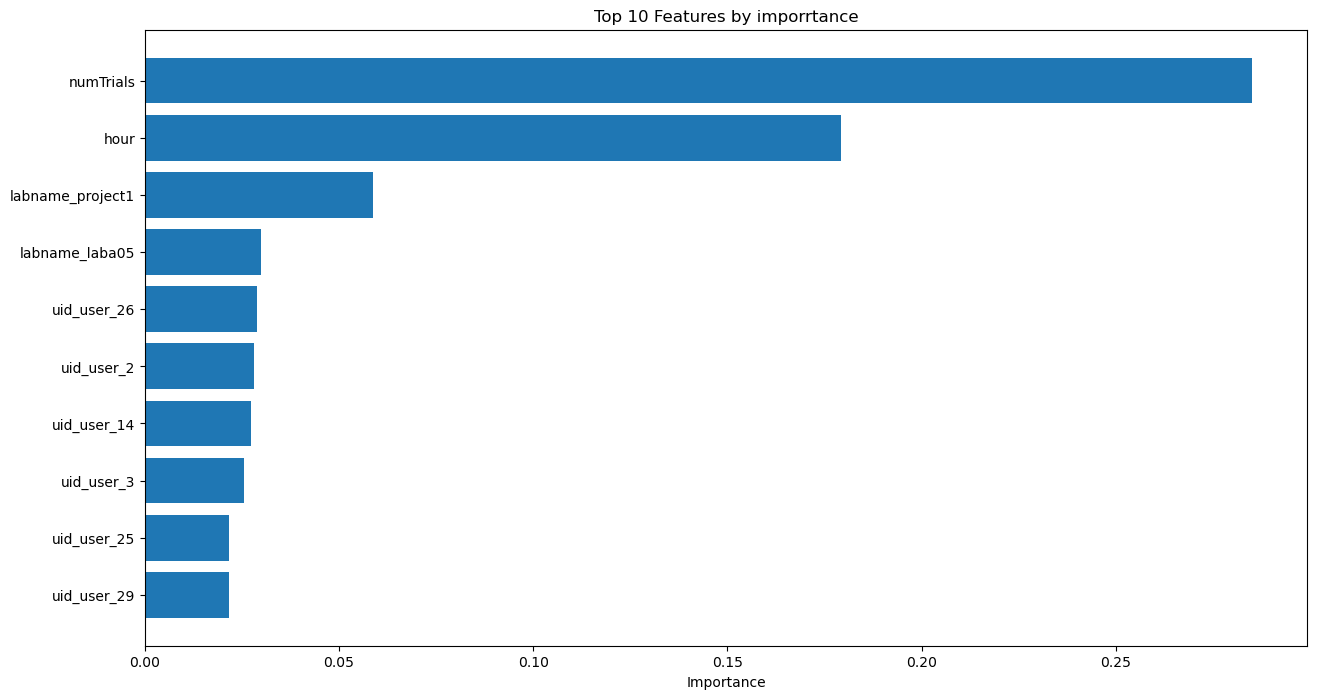

In [44]:
draw_barh(forest_coef, X.columns, 10)